<a href="https://colab.research.google.com/github/DHEVADHARSHINIV/GEN-AI/blob/main/GEN_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q \
torch==2.6.0 \
torchvision==0.21.0 \
torchaudio==2.6.0 \
transformers==4.53.2 \
datasets==3.6.0 \
accelerate \
evaluate \
scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 810.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import torch
import torchvision
import transformers
import datasets

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

from torchvision.io import VideoReader
print("✅ VideoReader imported successfully")

Torch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
Transformers: 4.53.2
Datasets: 3.6.0
✅ VideoReader imported successfully


In [3]:
from datasets import load_dataset

print("Loading IMDB dataset...")

dataset = load_dataset("imdb")

print(dataset)

Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
from transformers import AutoTokenizer

# Select the original experiment subset
small_train = dataset["train"].shuffle(seed=42).select(range(2000))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenization function
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

print("Tokenizing training dataset...")
train_ds = small_train.map(tokenize, batched=True)

print("Tokenizing test dataset...")
test_ds = small_test.map(tokenize, batched=True)

print("\nDone!")
print(train_ds)
print(test_ds)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training dataset...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing test dataset...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Done!
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 2000
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 500
})


In [5]:
from transformers import AutoModelForSequenceClassification

print("Loading DistilBERT model...")

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("✅ Model loaded successfully!")

Loading DistilBERT model...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully!


In [6]:
# ==========================================================
# EXPERIMENT 10
# Fine-Tuning DistilBERT on IMDB Sentiment Classification
# ==========================================================

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import numpy as np
from sklearn.metrics import accuracy_score

# -------------------------------
# 1. Load IMDB Dataset
# -------------------------------
print("Loading IMDB dataset...")
dataset = load_dataset("imdb")

small_train = dataset["train"].shuffle(seed=42).select(range(2000))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

# -------------------------------
# 2. Load Tokenizer
# -------------------------------
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

print("Tokenizing training data...")
train_ds = small_train.map(tokenize, batched=True)

print("Tokenizing test data...")
test_ds = small_test.map(tokenize, batched=True)

# -------------------------------
# 3. Load Pre-trained Model
# -------------------------------
print("Loading DistilBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# -------------------------------
# 4. Training Arguments
# -------------------------------
training_args = TrainingArguments(
    output_dir="./results",
    overwrite_output_dir=True,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    learning_rate=2e-5,
    report_to="none"
)

# -------------------------------
# 5. Accuracy Metric
# -------------------------------
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions)
    }

# -------------------------------
# 6. Trainer
# -------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

# -------------------------------
# 7. Train
# -------------------------------
print("\nStarting training...\n")
trainer.train()

# -------------------------------
# 8. Evaluate
# -------------------------------
metrics = trainer.evaluate()

print("\nEvaluation Metrics:")
print(metrics)

# -------------------------------
# 9. Save Model
# -------------------------------
model.save_pretrained("./fine_tuned_distilbert_imdb")
tokenizer.save_pretrained("./fine_tuned_distilbert_imdb")

print("\nFine-tuned model saved successfully!")

Loading IMDB dataset...
Loading tokenizer...
Tokenizing training data...
Tokenizing test data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading DistilBERT model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting training...



Epoch,Training Loss,Validation Loss,Accuracy
1,0.350600,0.440748,0.822000


Epoch,Training Loss,Validation Loss,Accuracy
1,0.350600,0.440748,0.822000
2,0.251800,0.505091,0.820000



Evaluation Metrics:
{'eval_loss': 0.5050908923149109, 'eval_accuracy': 0.82, 'eval_runtime': 68.9066, 'eval_samples_per_second': 7.256, 'eval_steps_per_second': 0.914, 'epoch': 2.0}

Fine-tuned model saved successfully!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Generating text...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Image saved as content_image.png


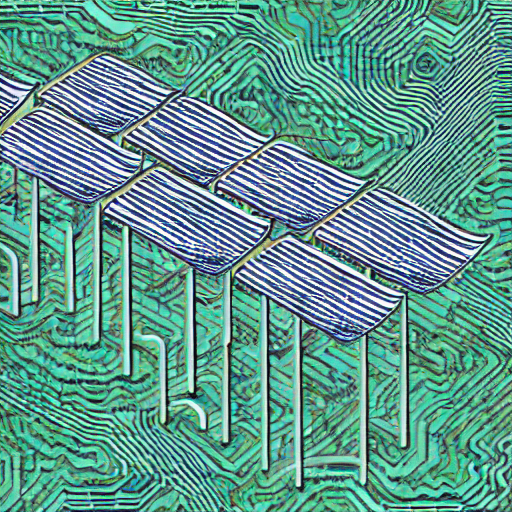


Generating audio...
Audio saved as content_audio.mp3


In [7]:
# EXP 11
!pip -q install diffusers transformers accelerate sentencepiece gTTS

from transformers import pipeline
from diffusers import StableDiffusionPipeline
from gtts import gTTS
from IPython.display import display, Audio

# -------------------------------
# Topic
# -------------------------------
topic = "The benefits of renewable energy"

# -------------------------------
# 1. Text Generation
# -------------------------------
print("Generating text...")

text_generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-base"
)

prompt = f"Write a short engaging paragraph about {topic}."

generated_text = text_generator(
    prompt,
    max_length=80
)[0]["generated_text"]

print("\nGenerated Text:\n")
print(generated_text)

# -------------------------------
# 2. Image Generation (CPU)
# -------------------------------
print("\nGenerating image... (This may take several minutes on CPU)")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
)

image_prompt = f"An illustration representing {topic}, digital art"

image = pipe(
    image_prompt,
    num_inference_steps=25
).images[0]

image.save("content_image.png")

print("Image saved as content_image.png")

display(image)

# -------------------------------
# 3. Text-to-Speech
# -------------------------------
print("\nGenerating audio...")

tts = gTTS(text=generated_text, lang="en")
tts.save("content_audio.mp3")

print("Audio saved as content_audio.mp3")

Audio("content_audio.mp3")

In [1]:
#EXP 12
import gradio as gr
from transformers import pipeline
import evaluate

# -----------------------------
# Load Summarization Model
# -----------------------------
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

# -----------------------------
# Summarization Function
# -----------------------------
def summarize_text(input_text):
    result = summarizer(
        input_text,
        max_length=45,
        min_length=15,
        do_sample=False
    )
    return result[0]["summary_text"]

# -----------------------------
# Gradio Interface
# -----------------------------
demo = gr.Interface(
    fn=summarize_text,
    inputs=gr.Textbox(
        lines=8,
        label="Enter text to summarize"
    ),
    outputs=gr.Textbox(
        label="Generated Summary"
    ),
    title="GenAI Text Summarizer",
    description="A cloud-deployable Generative AI summarization app built with Gradio."
)

# Launch
demo.launch(share=True)

# -----------------------------
# ROUGE Evaluation
# -----------------------------
rouge = evaluate.load("rouge")

generated_summaries = [
    "AI models generate new content such as text and images."
]

reference_summaries = [
    "Generative AI models are capable of producing new content including text and images."
]

scores = rouge.compute(
    predictions=generated_summaries,
    references=reference_summaries
)

print("\nROUGE Evaluation Scores:")
print(scores)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cpu


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0df8ecc2c312915b31.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



ROUGE Evaluation Scores:
{'rouge1': np.float64(0.608695652173913), 'rouge2': np.float64(0.380952380952381), 'rougeL': np.float64(0.608695652173913), 'rougeLsum': np.float64(0.608695652173913)}


In [3]:
!pip install -q rouge_score

  Preparing metadata (setup.py) ... done


In [3]:
!pip uninstall -y transformers -q

!pip install -q \
transformers==4.53.2 \
torch \
gradio \
evaluate \
sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.5 MB/s eta 0:00:00


In [1]:
import transformers

print("Transformers:", transformers.__version__)

from transformers.pipelines import SUPPORTED_TASKS
print("Summarization Available:",
      "summarization" in SUPPORTED_TASKS)

Transformers: 4.53.2


Summarization Available: True


In [5]:
!pip uninstall -y transformers -q

!pip install -q transformers==4.53.2